In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

In [3]:
df.sample(15)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
76495,Female,67.0,0,0,current,25.84,6.0,145,1
80476,Male,37.0,0,0,current,25.80,6.5,80,0
25824,Female,51.0,0,0,not current,27.32,4.8,90,0
99080,Male,57.0,1,0,former,27.32,6.5,240,1
927,Female,42.0,0,0,never,23.50,6.2,80,0
95336,Female,60.0,0,0,never,21.80,5.0,159,0
22303,Male,44.0,0,0,No Info,27.32,6.1,100,0
63774,Female,17.0,0,0,never,27.06,4.0,130,0
59440,Male,49.0,0,0,ever,26.53,6.1,159,0
83710,Female,59.0,0,0,never,24.80,4.0,145,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [5]:
df.duplicated().sum()

np.int64(3854)

In [6]:
df.isnull().mean()*100

gender                 0.0
age                    0.0
hypertension           0.0
heart_disease          0.0
smoking_history        0.0
bmi                    0.0
HbA1c_level            0.0
blood_glucose_level    0.0
diabetes               0.0
dtype: float64

In [7]:
df.shape

(100000, 9)

In [8]:
dupliated_rows = df[df.duplicated()]
print(dupliated_rows)

       gender   age  hypertension  heart_disease smoking_history    bmi  \
2756     Male  80.0             0              0         No Info  27.32   
3272   Female  80.0             0              0         No Info  27.32   
3418   Female  19.0             0              0         No Info  27.32   
3939   Female  78.0             1              0          former  27.32   
3960     Male  47.0             0              0         No Info  27.32   
...       ...   ...           ...            ...             ...    ...   
99980  Female  52.0             0              0           never  27.32   
99985    Male  25.0             0              0         No Info  27.32   
99989  Female  26.0             0              0         No Info  27.32   
99990    Male  39.0             0              0         No Info  27.32   
99995  Female  80.0             0              0         No Info  27.32   

       HbA1c_level  blood_glucose_level  diabetes  
2756           6.6                  159        

In [9]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [10]:
df['gender'].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [11]:
df = df[df['gender'] != 'Other']

In [12]:
df['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [13]:
df['gender'] = df['gender'].map({'Male':1, 'Female': 0})

In [14]:
df = pd.get_dummies(df, columns=['smoking_history'], drop_first=True, dtype=int)

In [15]:
df

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,0,80.0,0,1,25.19,6.6,140,0,0,0,0,1,0
1,0,54.0,0,0,27.32,6.6,80,0,0,0,0,0,0
2,1,28.0,0,0,27.32,5.7,158,0,0,0,0,1,0
3,0,36.0,0,0,23.45,5.0,155,0,1,0,0,0,0
4,1,76.0,1,1,20.14,4.8,155,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,0,36.0,0,0,24.60,4.8,145,0,0,0,0,0,0
99996,0,2.0,0,0,17.37,6.5,100,0,0,0,0,0,0
99997,1,66.0,0,0,27.83,5.7,155,0,0,0,1,0,0
99998,0,24.0,0,0,35.42,4.0,100,0,0,0,0,1,0


In [16]:
from sklearn.model_selection import train_test_split

X = df.drop(columns= ['diabetes'])
y = df['diabetes']

In [17]:
X_train,X_test,y_train,y_test = train_test_split (X,y, test_size=0.25, random_state=42)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [19]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced', max_iter=1000)

In [21]:
lr.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [22]:
y_pred_lr = lr.predict(X_test_scaled)

In [23]:
print("Train score:", lr.score(X_train_scaled, y_train))
print("Test score:", lr.score(X_test_scaled, y_test))

Train score: 0.8877607634265424
Test score: 0.8855276298268975


In [24]:
print('diabetes' in X.columns)

False


In [25]:
from sklearn.metrics import recall_score,precision_score,f1_score

In [26]:
y_pred = lr.predict(X_test_scaled)

In [27]:
print("Recall", recall_score (y_test,y_pred))

Recall 0.8750587130108032


In [28]:
print("precision", precision_score (y_test,y_pred))

precision 0.4284728610855566


In [29]:
print("F1 score", f1_score (y_test,y_pred))

F1 score 0.5752663270032422


In [30]:
from sklearn.metrics import accuracy_score
# Predictions aur accuracy
y_pred = lr.predict(X_test_scaled)
print("Corrected Accuracy:", accuracy_score(y_test, y_pred))

Corrected Accuracy: 0.8855276298268975


In [31]:
import numpy as np
print(np.unique(y_pred, return_counts=True))

(array([0, 1]), array([19684,  4348]))


In [32]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8855276298268975


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.99      0.89      0.93     21903
           1       0.43      0.88      0.58      2129

    accuracy                           0.89     24032
   macro avg       0.71      0.88      0.75     24032
weighted avg       0.94      0.89      0.90     24032



# Decision Tree

In [34]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)

In [35]:
dt.fit(X_train_scaled, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [36]:
y_pred_dt = dt.predict(X_test_scaled)

In [37]:
acc_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 0.9699151131824234


In [38]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     21903
           1       1.00      0.66      0.80      2129

    accuracy                           0.97     24032
   macro avg       0.98      0.83      0.89     24032
weighted avg       0.97      0.97      0.97     24032



# RandomForest

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, max_depth=8, random_state=42)

In [40]:
rf.fit(X_train_scaled, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 T

In [41]:
y_pred_rf = rf.predict(X_test_scaled)

In [42]:
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.9083305592543276


In [43]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      0.91      0.95     21903
           1       0.49      0.89      0.63      2129

    accuracy                           0.91     24032
   macro avg       0.74      0.90      0.79     24032
weighted avg       0.94      0.91      0.92     24032



# XGBoost 

In [44]:
!pip install xgboost

In [45]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    scale_pos_weight=6,
    random_state=42,
    eval_metric='logloss'
)

In [46]:
xgb.fit(X_train_scaled, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [47]:
X_train_scaled

array([[ 1.18281092, -0.03445836, -0.28910218, ..., -0.32826013,
        -0.74552325, -0.26506815],
       [-0.84544367, -1.23496965, -0.28910218, ..., -0.32826013,
        -0.74552325, -0.26506815],
       [-0.84544367, -1.50174994, -0.28910218, ..., -0.32826013,
        -0.74552325, -0.26506815],
       ...,
       [-0.84544367,  1.21051632, -0.28910218, ..., -0.32826013,
         1.34133979, -0.26506815],
       [-0.84544367, -0.21231188, -0.28910218, ..., -0.32826013,
         1.34133979, -0.26506815],
       [ 1.18281092, -0.83479922, -0.28910218, ..., -0.32826013,
        -0.74552325, -0.26506815]], shape=(72096, 12))

In [48]:
y_pred_xgb = xgb.predict(X_test_scaled)

In [49]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.98      0.95      0.97     21903
           1       0.62      0.85      0.72      2129

    accuracy                           0.94     24032
   macro avg       0.80      0.90      0.84     24032
weighted avg       0.95      0.94      0.94     24032



# KNN

In [50]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5, weights='distance')

In [51]:
knn.fit(X_train_scaled, y_train)

,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [52]:
y_pred_knn = knn.predict(X_test_scaled)

In [53]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98     21903
           1       0.84      0.60      0.70      2129

    accuracy                           0.95     24032
   macro avg       0.90      0.80      0.84     24032
weighted avg       0.95      0.95      0.95     24032



# Ada boost 

In [54]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report

# 1. Initialize AdaBoost
ada = AdaBoostClassifier(n_estimators=100, random_state=42)

# 2. Fit on raw training data
ada.fit(X_train_scaled, y_train)

# 3. Predict on raw test data
y_pred_ada = ada.predict(X_test_scaled)

print(classification_report(y_test, y_pred_ada))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     21903
           1       1.00      0.66      0.80      2129

    accuracy                           0.97     24032
   macro avg       0.98      0.83      0.89     24032
weighted avg       0.97      0.97      0.97     24032



# SVM

In [55]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

In [56]:
svm.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [57]:
y_pred_svm = svm.predict(X_train_scaled)

In [58]:
# Sahi: X_test_scaled use karein
y_pred_svm = svm.predict(X_test_scaled)

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98     21903
           1       0.89      0.60      0.71      2129

    accuracy                           0.96     24032
   macro avg       0.92      0.80      0.85     24032
weighted avg       0.96      0.96      0.95     24032



# SMOTE

In [59]:
!pip install imbalanced-learn

In [60]:
!pip install --upgrade imbalanced-learn

In [61]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

In [62]:
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [63]:
X_train_scaled_sm, y_train_scaled_sm = smote.fit_resample(X_train_scaled, y_train)

In [64]:
print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())

Before SMOTE:
diabetes
0    65743
1     6353
Name: count, dtype: int64

After SMOTE:
diabetes
0    65743
1    65743
Name: count, dtype: int64


In [65]:
from sklearn.ensemble import RandomForestClassifier

rf_smote = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)

In [66]:
rf_smote.fit(X_train_sm, y_train_sm)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [67]:
y_pred_rf_smote = rf_smote.predict(X_test)

In [68]:
print(classification_report(y_test, y_pred_rf_smote))

              precision    recall  f1-score   support

           0       0.98      0.91      0.95     21903
           1       0.49      0.84      0.62      2129

    accuracy                           0.91     24032
   macro avg       0.73      0.88      0.78     24032
weighted avg       0.94      0.91      0.92     24032



Bad value in file WindowsPath('C:/Users/MrAhs/anaconda3/Lib/site-packages/matplotlib/mpl-data/stylelib/classic.mplstyle'), line 162 ('mathtext.default: normal  # The default font to use for math.'): Key mathtext.default: 'normal' is not a valid value for mathtext.default; supported values are ['rm', 'cal', 'bfit', 'it', 'tt', 'sf', 'bf', 'default', 'bb', 'frak', 'scr', 'regular']

Bad key axes3d.depthshade in file C:\Users\MrAhs\anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\classic.mplstyle, line 225 ('axes3d.depthshade   : False   # depth shade for 3D scatter plots')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.0/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution

Bad key axes3d.depthshade_minalpha in file C:\Users\MrAhs\anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\classic.mplstyle, line 226 ('axes3d.depthshade_minalpha : 0.3  # minimum alpha value for depth shading')


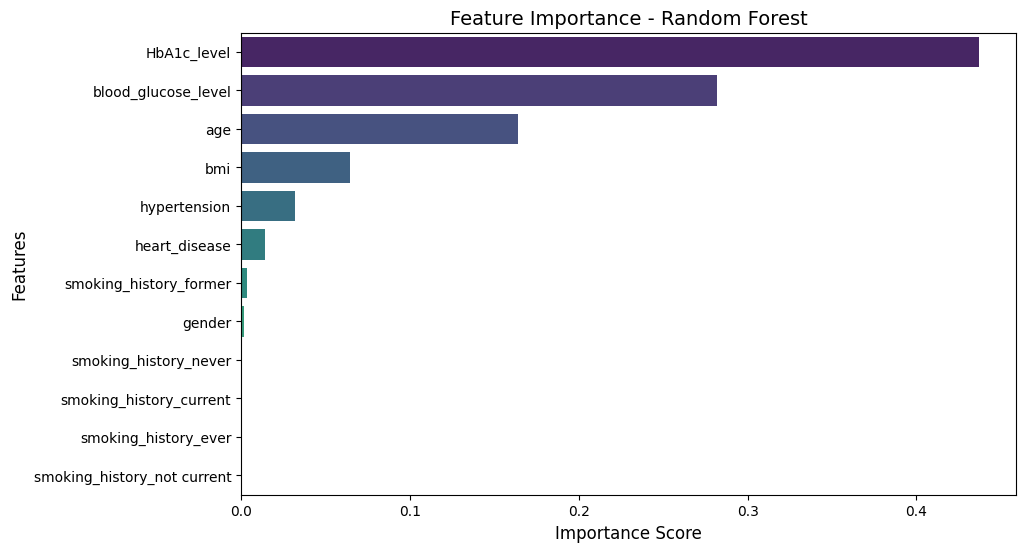

Top Most Important Features:
HbA1c_level                    0.437128
blood_glucose_level            0.281708
age                            0.163989
bmi                            0.064334
hypertension                   0.031873
heart_disease                  0.014173
smoking_history_former         0.003611
gender                         0.001566
smoking_history_never          0.000774
smoking_history_current        0.000372
smoking_history_ever           0.000301
smoking_history_not current    0.000172
dtype: float64


In [69]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Feature importances ko DataFrame mein convert karein
feature_names = X.columns
rf_importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

# Barplot banayein
plt.figure(figsize=(10, 6))
sns.barplot(x=rf_importances.values, y=rf_importances.index, palette='viridis')
plt.title('Feature Importance - Random Forest', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()


# Top features print karein
print("Top Most Important Features:")
print(rf_importances)

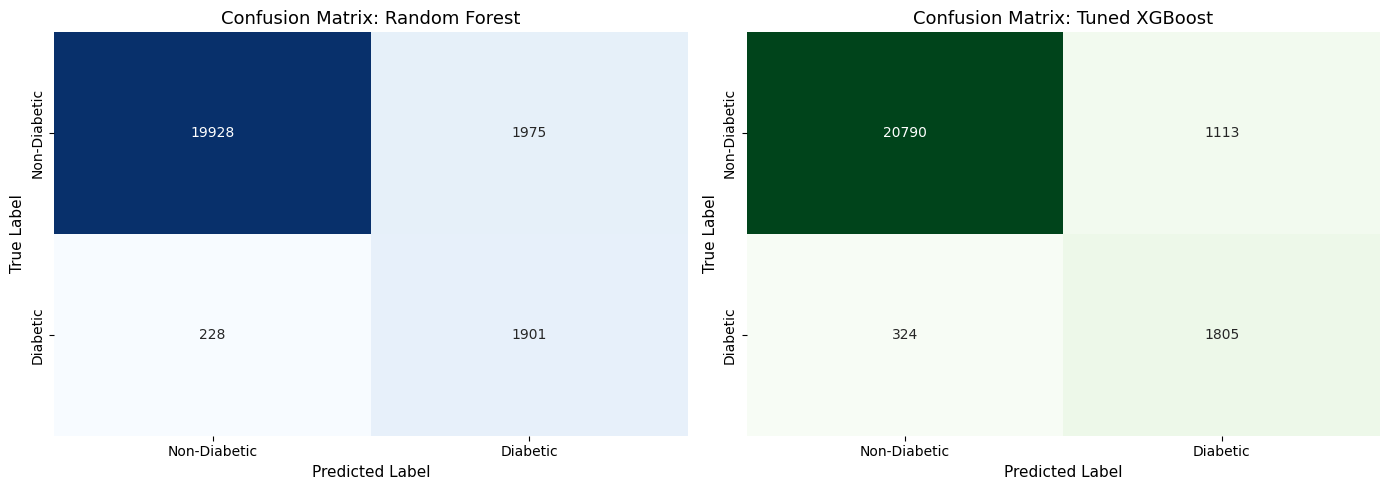

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Confusion matrices calculate karein
cm_rf = confusion_matrix(y_test, y_pred_rf)        # Default/Balanced RF
cm_xgb = confusion_matrix(y_test, y_pred_xgb)    # XGBoost (scale_pos_weight=4)

# 2. Side-by-side plot setup
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest Heatmap
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
axes[0].set_title('Confusion Matrix: Random Forest', fontsize=13)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

# XGBoost Tuned Heatmap
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1],
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
axes[1].set_title('Confusion Matrix: Tuned XGBoost', fontsize=13)
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.show()

# save model

In [71]:
import joblib

#XGBoost model
joblib.dump(xgb, 'Diabetes_model.pkl')
print("Model successfully saved as Diabetes_model.pkl")
joblib.dump(list(X.columns), 'diabetes_features.pkl')

Model successfully saved as Diabetes_model.pkl


['diabetes_features.pkl']

In [72]:
df.sample(15)

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
8497,0,33.0,0,0,27.32,4.0,130,0,0,0,0,1,0
95961,0,45.0,0,0,50.05,6.0,300,1,1,0,0,0,0
49350,1,61.0,0,0,27.32,5.7,126,1,0,0,0,1,0
51867,1,58.0,1,0,33.76,5.0,160,0,0,0,1,0,0
26005,1,80.0,0,1,24.39,6.2,160,0,0,0,0,1,0
31483,0,59.0,0,0,23.80,6.5,140,1,0,0,0,0,1
66932,0,39.0,0,0,27.56,6.1,155,0,1,0,0,0,0
14304,0,80.0,0,0,33.39,5.8,145,0,0,0,0,1,0
2505,1,24.0,0,0,39.93,4.8,145,0,0,0,0,0,0
88832,0,63.0,0,0,28.62,5.8,140,0,0,0,0,0,0


# Test the Model

In [73]:
# Enter any row number
row_no = 42540

# 1. Real value
real_ans = df.loc[row_no, 'diabetes']

# 2. Model prediction
sample_data = scaler.transform(df.drop(columns=['diabetes']).loc[[row_no]])
model_pred = xgb.predict(sample_data)[0]

# 3. Output
print(f"Row Number       : {row_no}")
print(f"Real Answer      : {real_ans}")
print(f"Model Prediction : {model_pred}")

Row Number       : 42540
Real Answer      : 1
Model Prediction : 1


# Test on new data

In [74]:
import numpy as np
import pandas as pd

# 1. Naye Mareez ka Data (Values apni marzi se change karein)
new_patient = pd.DataFrame(
    [
        {
     'gender': 0,
    'age': 52.0,
    'hypertension': 1,
    'heart_disease': 0,
    'bmi': 34.2,
    'HbA1c_level': 5.2,
    'blood_glucose_level': 95,
    'smoking_history_current': 0,
    'smoking_history_ever': 0,
    'smoking_history_former': 0,
    'smoking_history_never': 1,
    'smoking_history_not current': 0
        }
    ]
)

# 2. Scaler se transform karein
scaled_data = scaler.transform(new_patient)

# 3. Prediction & Probability
pred = xgb.predict(scaled_data)[0]
prob = xgb.predict_proba(scaled_data)[0][1] * 100

# 4. Result
print(f"Prediction : {pred} ({'Diabetic' if pred == 1 else 'Non-Diabetic'})")
print(f"Risk Level : {prob:.2f}%")

Prediction : 0 (Non-Diabetic)
Risk Level : 0.01%


In [75]:
import joblib
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# 1. Scaler aur Model ko ek single pipeline mein daal dein
pipeline = Pipeline([
    ('scaler', scaler), # Jo StandardScaler aapne pehle banaya tha
    ('xgb', xgb)        # Trained XGBoost model
])

# 2. Sirf ek single file save karein
joblib.dump(pipeline, 'model.pkl')
print("Complete pipeline successfully saved as model.pkl")

Complete pipeline successfully saved as model.pkl
